In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
from sklearn.impute import SimpleImputer
import platform
import os


In [2]:
current_path = os.getcwd()

In [3]:
def find_suitable_font():
    """查找系统中可用的中文字体"""
    chinese_fonts = ['SimHei', 'WenQuanYi Micro Hei', 'Heiti TC', 
                    'Microsoft YaHei', 'SimSun', 'WenQuanYi Micro Hei',
                    'Heiti TC', 'Arial Unicode MS']
    
    for font in chinese_fonts:
        if font in [f.name for f in fm.fontManager.ttflist]:
            return font
    return None  # 如果没有找到任何中文字体

In [4]:
# 设置中文字体
font = find_suitable_font()
if font:
    plt.rcParams["font.family"] = font
    print(f"已使用中文字体: {font}")
else:
    print("警告: 未找到可用的中文字体，图表中的中文可能无法正常显示")

# 设置图片清晰度
plt.rcParams['figure.dpi'] = 300

# 正常显示负号
plt.rcParams['axes.unicode_minus'] = False

已使用中文字体: SimHei


In [7]:
# 加载数据
data1_path=current_path+"\\data\\accepts.csv"
df = pd.read_csv(data1_path, sep=';')

柱状图已保存至: output\不良标识与破产记录分组统计.png


<Figure size 3000x1800 with 0 Axes>

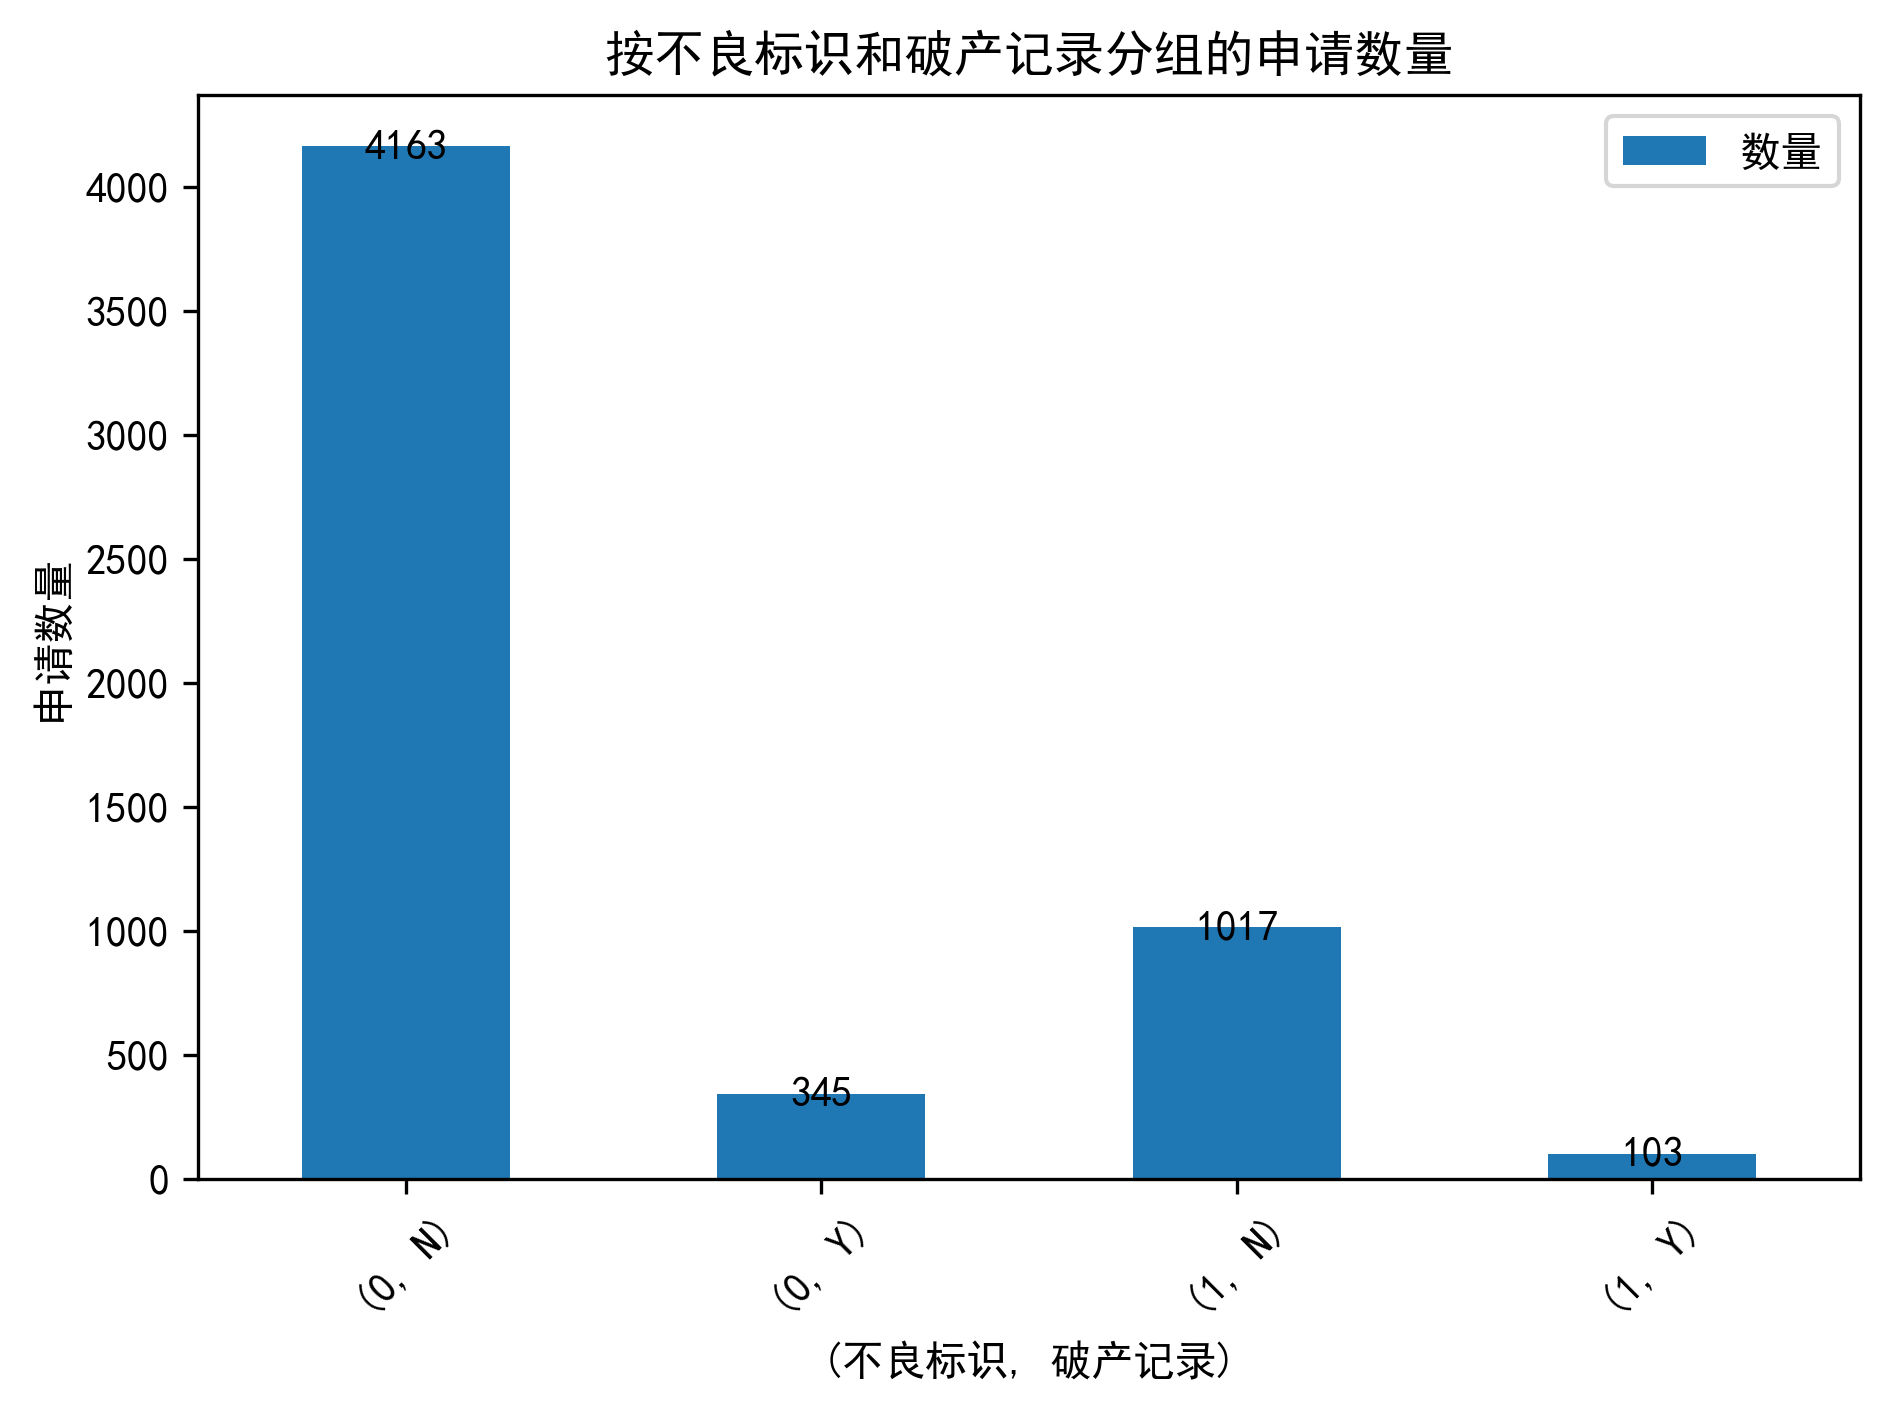

ROC曲线图已保存至: G:\JupyterNotebook\Internship\Stage3\output\不良标识与破产记录的ROC曲线.png


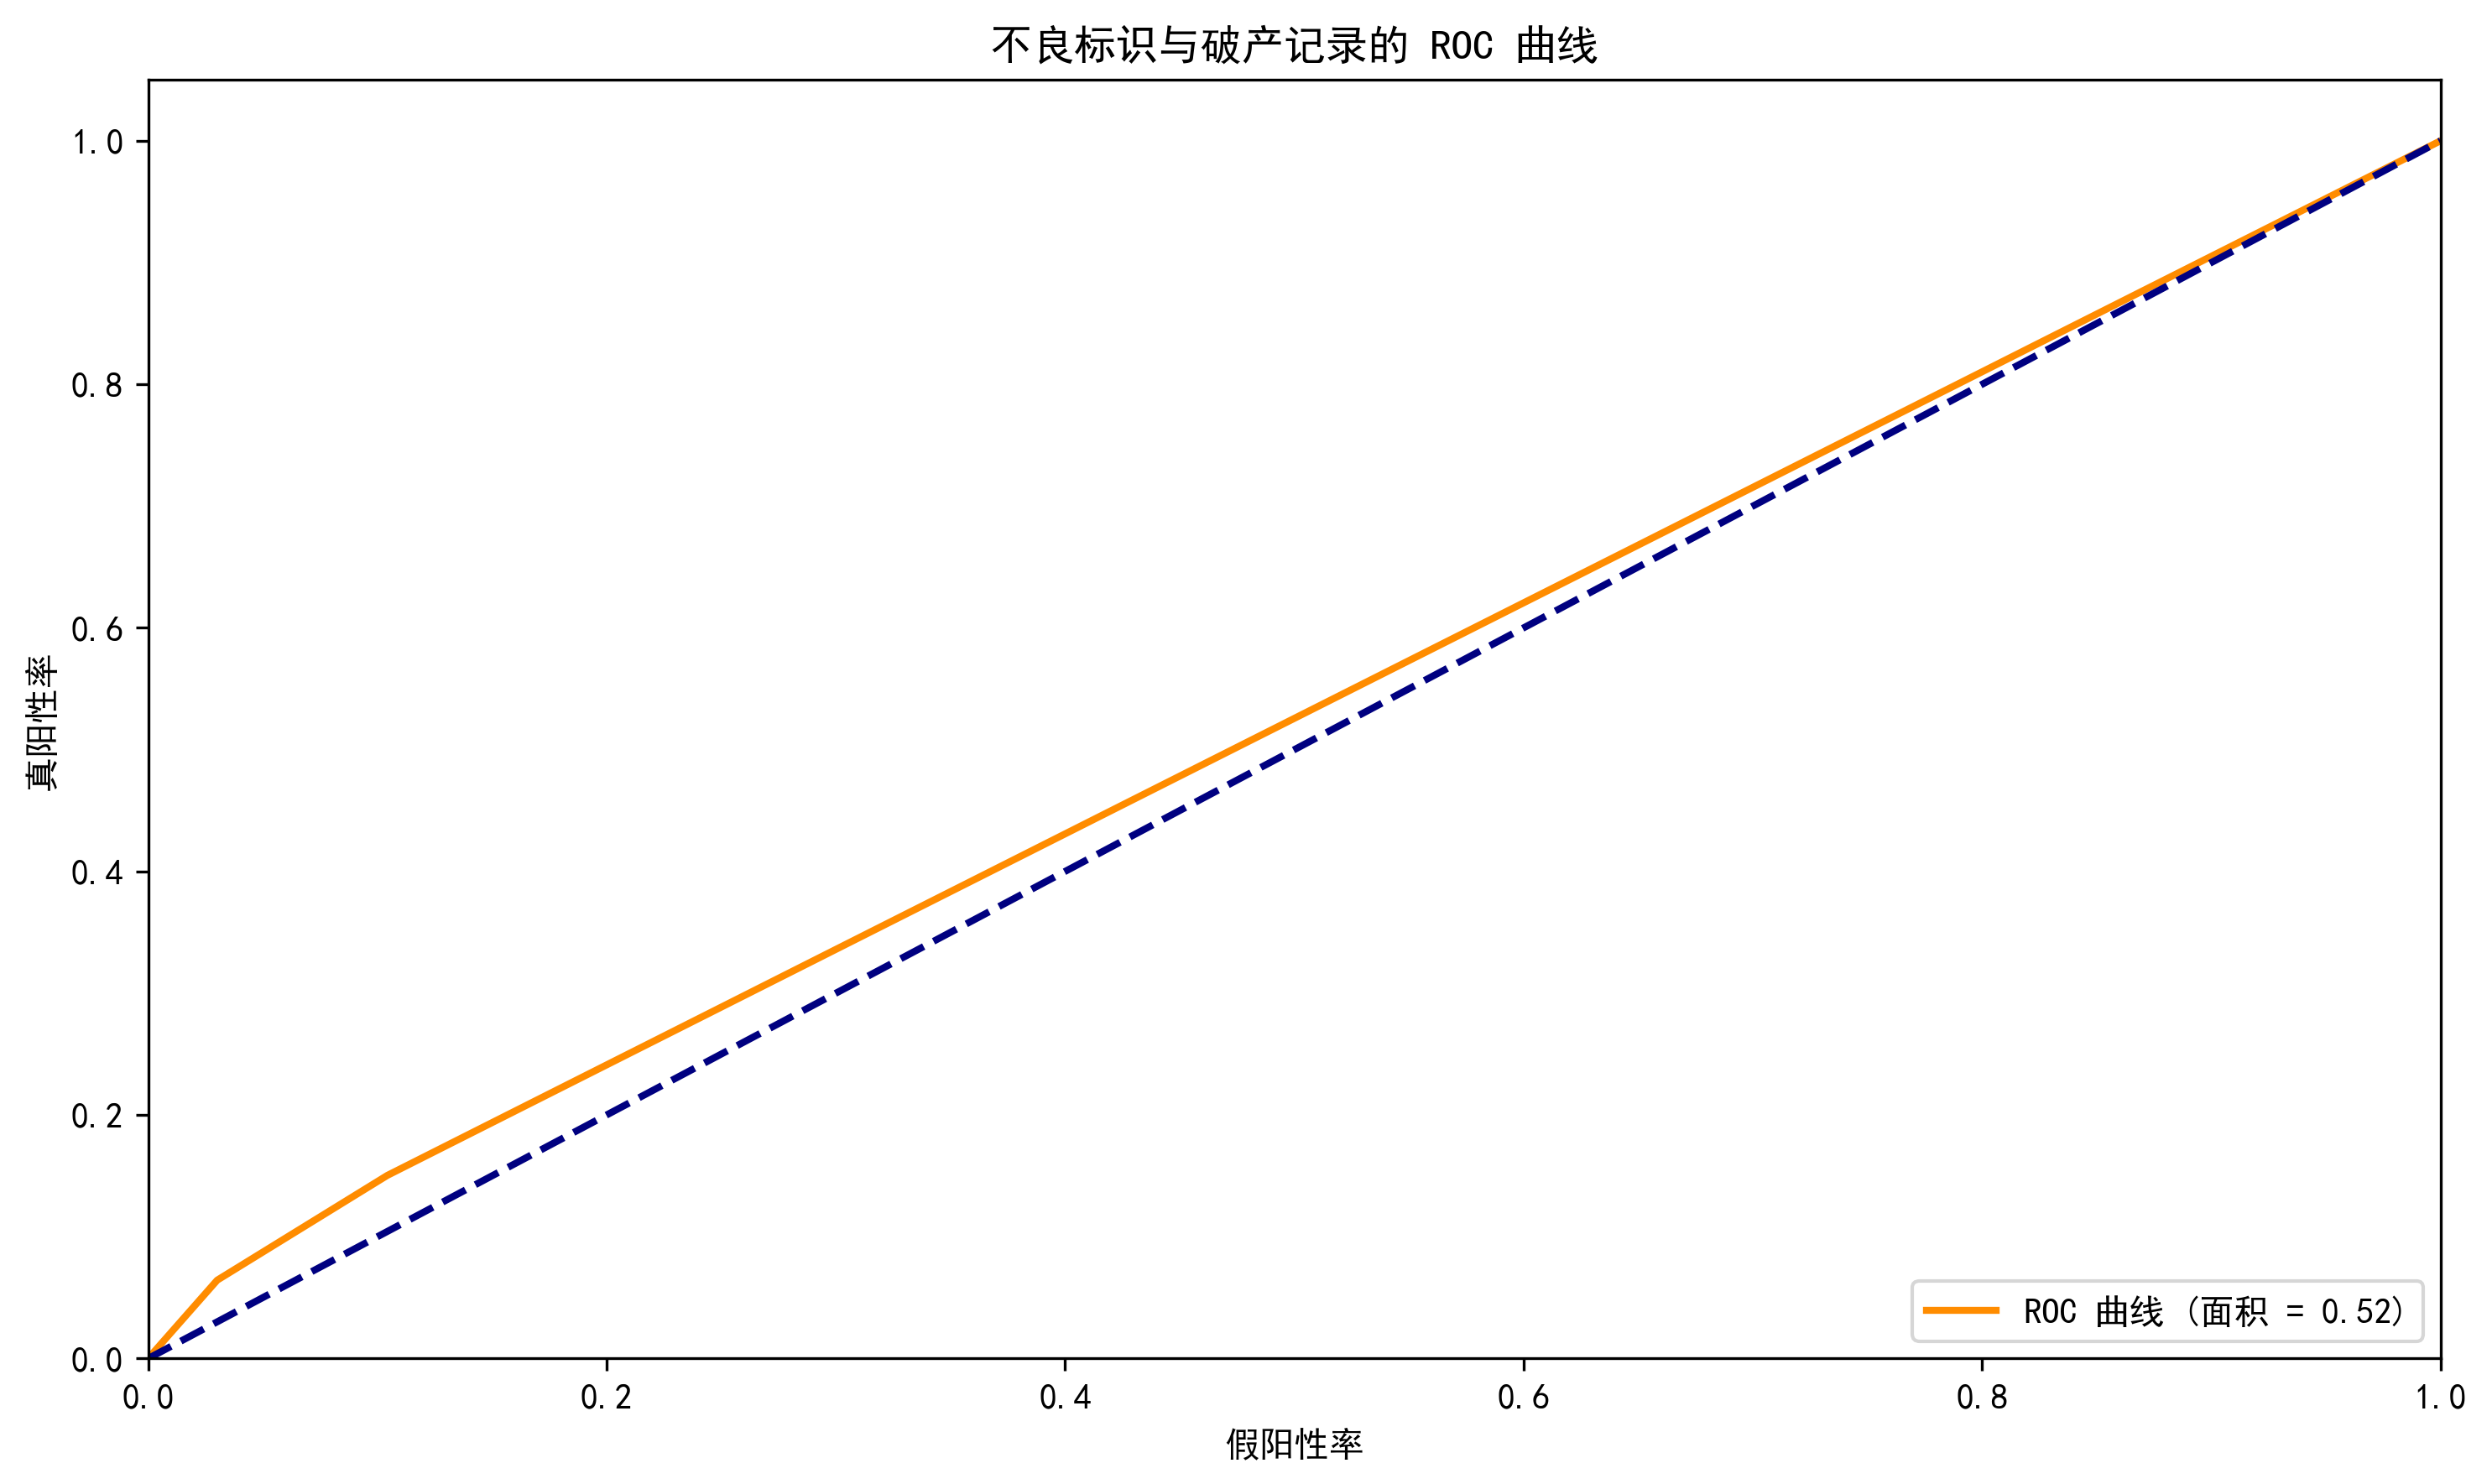

In [12]:
# 按 bad_ind 和 bankruptcy_ind 列进行分组，并统计每组的数量
classify_df = df.groupby(['bad_ind', 'bankruptcy_ind'])[['application_id']].count().rename(columns={'application_id': '数量'})

# 创建保存图片的目录
if not os.path.exists('output'):
    os.makedirs('output')

# 绘制柱状图展示分组统计结果
plt.figure(figsize=(10, 6))  # 设置图表大小
ax = classify_df.plot(kind='bar')

# 遍历每个柱子添加数据标签
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.annotate(height, (x + width / 2, y + height), ha='center', va='center')

# 设置标题和标签
plt.title('按不良标识和破产记录分组的申请数量')
plt.xlabel('(不良标识, 破产记录)')
plt.ylabel('申请数量')
plt.xticks(rotation=45)
plt.tight_layout()  # 调整布局，确保标签完整显示

# 保存柱状图
bar_chart_path = 'output\\不良标识与破产记录分组统计.png'
plt.savefig(bar_chart_path)
print(f"柱状图已保存至: {bar_chart_path}")

# 显示图形
plt.show()

# 准备数据用于计算 ROC 曲线
# 将 bankruptcy_ind 进行编码
df['bankruptcy_ind_encoded'] = LabelEncoder().fit_transform(df['bankruptcy_ind'])

# 计算 FPR, TPR 和阈值
fpr, tpr, thresholds = roc_curve(df['bad_ind'], df['bankruptcy_ind_encoded'])
roc_auc = auc(fpr, tpr)

# 绘制 ROC 曲线
plt.figure(figsize=(10, 6))  # 设置图表大小
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC 曲线 (面积 = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假阳性率')
plt.ylabel('真阳性率')
plt.title('不良标识与破产记录的 ROC 曲线')
plt.legend(loc='lower right')
plt.tight_layout()  # 调整布局，确保标签完整显示

# 保存ROC曲线图
roc_curve_path = current_path+'\\output\\不良标识与破产记录的ROC曲线.png'
plt.savefig(roc_curve_path)
print(f"ROC曲线图已保存至: {roc_curve_path}")

# 显示图形
plt.show()

In [15]:
# 设置中文字体支持
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题
data2_path=current_path+"\\data\\accepts.csv"

# 读取CSV文件
try:
    # 使用分号分隔符读取文件
    df = pd.read_csv(data2_path, sep=';')
    print(f"数据基本信息：")
    df.info()
    
    # 数据预处理
    # 检查缺失值
    missing_values = df.isnull().sum()
    print("\n缺失值统计：")
    print(missing_values[missing_values > 0])
    
    # 手动检查数据类型和内容
    print("\n数据类型和内容检查：")
    print("数据前几行：")
    print(df.head().to_string())  # 显示完整列名
    
    # 确定目标变量
    target_variable = 'bad_ind'  # 根据实际情况修改
    
    # 验证目标变量是否存在
    if target_variable not in df.columns:
        raise ValueError(f"目标变量 '{target_variable}' 不在数据列中，请检查列名。")
    
    # 处理缺失值
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    
    # 确保目标变量不在分类列列表中
    if target_variable in categorical_cols:
        categorical_cols.remove(target_variable)
    
    print(f"\n数值列 ({len(numeric_cols)}): {numeric_cols}")
    print(f"分类列 ({len(categorical_cols)}): {categorical_cols}")
    
    # 对数值型列用中位数填充
    imputer_num = SimpleImputer(strategy='median')
    df[numeric_cols] = imputer_num.fit_transform(df[numeric_cols])
    
    # 对分类型列用众数填充
    imputer_cat = SimpleImputer(strategy='most_frequent')
    df[categorical_cols] = imputer_cat.fit_transform(df[categorical_cols])
    
    # 编码分类变量
    for col in categorical_cols:
        print(f"编码分类列: {col}")
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
    
    # 准备特征和目标变量
    X = df.drop([target_variable], axis=1)
    y = df[target_variable]
    
    # 验证特征矩阵是否为空
    if X.shape[1] == 0:
        raise ValueError("特征矩阵为空，请检查数据处理步骤。")
    
    print(f"\n特征矩阵形状: {X.shape}")
    print(f"目标变量形状: {y.shape}")
    
    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # 特征标准化
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 模型训练（使用随机森林分类器）
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # 模型预测
    y_pred = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # 评估模型
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n模型准确率: {accuracy:.2f}")
    
    print("\n分类报告:")
    print(classification_report(y_test, y_pred))
    
    # 可视化
    print("开始生成可视化图表...")
    plt.figure(figsize=(15, 10))
    
    # 子图1：分类数量可视化
    plt.subplot(2, 2, 1)
    sns.countplot(x=target_variable, data=df)
    plt.title('分类数量分布')
    plt.xlabel('类别')
    plt.ylabel('数量')
    
    # 添加数值标签
    for p in plt.gca().patches:
        plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                          ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                          textcoords='offset points')
    
    # 子图2：混淆矩阵
    plt.subplot(2, 2, 2)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('混淆矩阵')
    plt.xlabel('预测类别')
    plt.ylabel('实际类别')
    
    # 子图3：特征重要性
    plt.subplot(2, 2, 3)
    feature_importances = pd.Series(model.feature_importances_, index=X.columns)
    feature_importances.nlargest(10).plot(kind='barh')
    plt.title('特征重要性')
    plt.xlabel('重要性')
    plt.tight_layout()
    
    # 子图4：ROC曲线
    plt.subplot(2, 2, 4)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC曲线 (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('假阳性率')
    plt.ylabel('真阳性率')
    plt.title('ROC曲线')
    plt.legend(loc="lower right")
    
    plt.tight_layout()
    
    # 保存图像
    print("正在保存图像...")
    plt.savefig(current_path+'\\output\\classification_analysis.png', dpi=300, bbox_inches='tight')
    print("图像已保存为 classification_analysis.png")
    
    # 显示图像
    print("显示可视化图表...")
    
    # 尝试设置matplotlib后端
    try:
        import matplotlib
        matplotlib.use('TkAgg')  # 使用TkAgg后端
        plt.switch_backend('TkAgg')
    except:
        print("无法设置TkAgg后端，使用默认后端")
    
    plt.show()  # 显示图像
    
    print("程序执行完毕!")
    
except FileNotFoundError:
    print("错误：找不到'accepts.csv'文件，请确保文件在正确的路径下。")
except ValueError as ve:
    print(f"值错误: {ve}")
except Exception as e:
    print(f"发生未知错误：{e}")
    # 打印详细的堆栈信息，帮助定位问题
    import traceback
    print(traceback.format_exc())    

数据基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5845 entries, 0 to 5844
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  5845 non-null   int64  
 1   account_number  5845 non-null   int64  
 2   bad_ind         5845 non-null   int64  
 3   vehicle_year    5844 non-null   float64
 4   vehicle_make    5546 non-null   object 
 5   bankruptcy_ind  5628 non-null   object 
 6   tot_derog       5632 non-null   float64
 7   tot_tr          5632 non-null   float64
 8   age_oldest_tr   5629 non-null   float64
 9   tot_open_tr     4426 non-null   float64
 10  tot_rev_tr      5207 non-null   float64
 11  tot_rev_debt    5367 non-null   float64
 12  tot_rev_line    5367 non-null   float64
 13  rev_util        5845 non-null   int64  
 14  fico_score      5531 non-null   float64
 15  purch_price     5845 non-null   float64
 16  msrp            5844 non-null   float64
 17  down_pyt        5845 non-

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

正在保存图像...


findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: 

图像已保存为 classification_analysis.png
显示可视化图表...
程序执行完毕!
